# 02 Base Model
**Owner:** Group

This notebook handles categorical encoding, dataset splitting, training the base RandomForest model, and saving the artifacts for later ethical evaluation.


In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import joblib
import matplotlib.pyplot as plt

from src.data_loader import load_oulad, encode_categoricals, get_feature_columns
from src.model import build_splits, train_model, evaluate_model

## 1. Load & Prepare Data


In [2]:
df = load_oulad()
df = encode_categoricals(df)
feature_cols, sensitive_cols = get_feature_columns(df)

# Combine continuous features and encoded categorical features for modeling
encoded_feature_cols = feature_cols + [c + "_enc" for c in sensitive_cols if c + "_enc" in df.columns]
print("Features used for training:", encoded_feature_cols)

Features used for training: ['total_clicks', 'vle_days', 'weighted_score', 'submission_rate', 'num_of_prev_attempts', 'studied_credits', 'gender_enc', 'disability_enc', 'imd_band_enc', 'age_band_enc', 'highest_education_enc']


## 2. Train/Test Split


In [3]:
X_train, X_test, y_train, y_test = build_splits(df, encoded_feature_cols)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (26074, 11)
X_test shape: (6519, 11)


## 3. Model Training


In [4]:
model = train_model(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


## 4. Evaluation


In [5]:
metrics = evaluate_model(model, X_test, y_test)
print("--- Classification Report ---")
print(metrics['report'])
print(f"ROC-AUC Score: {metrics['roc_auc']:.3f}")

--- Classification Report ---
              precision    recall  f1-score   support

        Pass       0.82      0.89      0.86      3077
     At-Risk       0.90      0.83      0.86      3442

    accuracy                           0.86      6519
   macro avg       0.86      0.86      0.86      6519
weighted avg       0.86      0.86      0.86      6519

ROC-AUC Score: 0.941


## 5. Feature Importance


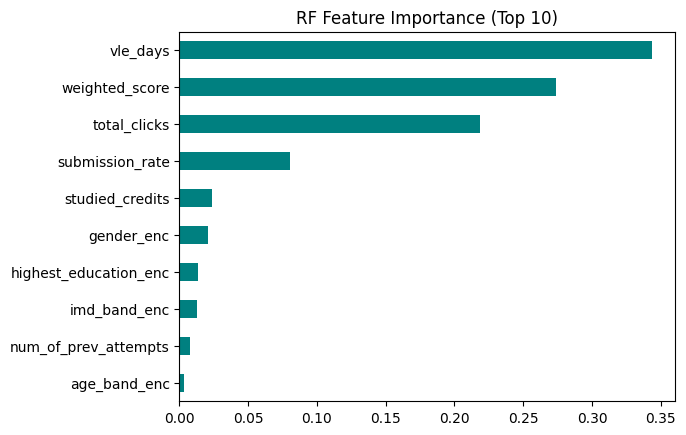

In [6]:
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances.nlargest(10).plot(kind='barh', title='RF Feature Importance (Top 10)', color='teal')
plt.gca().invert_yaxis()
plt.show()

## 6. Save Artifacts
Save the model and test splits for the Transparency, Fairness, and Privacy modules.


In [7]:
data_dir = Path.cwd().parent / 'data'
data_dir.mkdir(exist_ok=True)

joblib.dump(model, data_dir / 'base_model.pkl')
joblib.dump(X_train, data_dir / 'X_train.pkl')
joblib.dump(X_test, data_dir / 'X_test.pkl')
joblib.dump(y_test, data_dir / 'y_test.pkl')

print("Artifacts saved to code/data/")

Artifacts saved to code/data/
